# 8.15 Optical Absorption and Excitons

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume VIII — Electronic Structure and Many-Body Matter",
    number="8.15",
    title="Optical Absorption and Excitons",
    blurb="What does light see in a crystal? The dielectric function "
    "ε₂(ω) of real silicon, computed from the three form factors of §8.11 "
    "with proper dipole matrix elements: the famous E₂ peak lands at "
    "4.26 eV with height 39.5 against the measured 4.3 eV and ≈40, and "
    "the f-sum rule — checked in absolute units against ℏω_p = 16.6 eV "
    "from scipy.constants — diagnoses exactly what the truncated band "
    "sum leaves out (67% → 95% as conduction bands are added). Then the "
    "part independent particles cannot do: the electron and its hole "
    "attract, a hydrogen problem inside a solid gives GaAs its 4.7 meV "
    "exciton at radius 11.8 nm, and a model Bethe–Salpeter equation "
    "pulls a bound state below the continuum carrying 45% of the "
    "spectrum's oscillator strength.",
    difficulty="advanced",
    estimate="150–180 min",
)

<ECP header: 3110 chars of HTML>

## Notebook overview

[§8.14](quasiparticles-gw.ipynb) built the spectra of *charged*
excitations — add or remove one electron. Optics asks a different
question: shine light on the crystal and the photon creates an electron
*and* a hole at the same time, at (almost) the same crystal momentum.
The independent-particle answer is a golden-rule sum
([§6.24](../06-quantum-mechanics/time-dependent-perturbation.ipynb)) over
vertical transitions weighted by dipole matrix elements, and this
notebook computes it for *real silicon and gallium arsenide* — no toy
bands, but the empirical pseudopotential machinery of
[§8.11](epm-band-structures.ipynb), whose plane-wave eigenvectors make
the momentum matrix elements a one-line `numpy.einsum`. The results are
startling for a three-parameter model: silicon's celebrated $E_2$
absorption peak computed at $4.26$ eV with $\varepsilon_2 = 39.5$
against the measured $4.3$ eV and $\approx 40$ {cite}`yucardona2010`,
GaAs's absorption edge at its direct gap, and the Thomas–Reiche–Kuhn
$f$-sum rule — evaluated in *absolute SI units* against
$\hbar\omega_p = 16.60$ eV from `scipy.constants` and the silicon
valence density — satisfied to $93\%$ by four conduction bands, with
the missing weight recovered band by band ($67\% \to 88\% \to 95\%$):
a sum rule working as an audit of truncation, exactly as in
[§8.14](quasiparticles-gw.ipynb).

Then the physics independent particles cannot produce. The
photo-created electron and hole attract; bound electron–hole states —
**excitons** {cite}`wannier1937` — appear *inside* the quasiparticle
gap, and the absorption spectrum is rebuilt. Two computations close the
volume-long arc: the Wannier exciton of GaAs as a scaled hydrogen atom
([§6.17](../06-quantum-mechanics/hydrogen-atom.ipynb)'s solution wearing
$\mu = 0.058\,m_e$ and $\varepsilon_r = 12.9$) — binding $4.74$ meV
against the measured $4.2$, radius $11.8$ nm spanning twenty unit
cells, the self-consistency of the effective-mass picture checked
rather than assumed — and a two-band model **Bethe–Salpeter equation**
{cite}`rohlfing2000`: an electron–hole Hamiltonian on a $k$-grid whose
contact attraction pulls one state $0.236t$ below the continuum edge
and hands it $45\%$ of the entire spectrum's oscillator strength,
with the total conserved to $10^{-10}$ — the same weight-shuffling
bookkeeping the sum rules have enforced all volume.

> **Conventions (this notebook).** EPM exactly as
> [§8.11](epm-band-structures.ipynb): Cohen–Bergstresser form factors,
> $\tau = (a/8)(1,1,1)$, $|\mathbf G|^2 \leq 24$ ($137$ plane waves),
> energies in eV with the kinetic scale from `scipy.constants`.
> Brillouin-zone averages are Monte Carlo over the *reciprocal
> primitive cell* ($\mathbf k = x_1\mathbf b_1 + x_2\mathbf b_2 +
> x_3\mathbf b_3$, $x_i$ uniform — equivalent to the BZ by
> periodicity), `numpy.random.default_rng(1966)`. Dipole (momentum)
> matrix elements $\langle v|\hat{\mathbf p}|c\rangle = \hbar
> \tfrac{2\pi}{a}\sum_{\mathbf G} c_v^*(\mathbf G)\,(\mathbf k +
> \mathbf G)\,c_c(\mathbf G)$, isotropically averaged. Lorentzian
> broadening $\eta = 0.15$ eV for spectra. The BSE toy uses hopping
> units ($t = 1$).
>
> **How to read the checks.** Each exercise closes with a `validate`
> call against an independent fact: a measured landmark, an absolute
> sum rule from `scipy.constants`, a conservation law. A ✓ is strong
> evidence; a ✗ is a prompt to locate the discrepancy, not an
> automatic verdict.
>
> **Scope.** Independent-particle $\varepsilon_2$ plus model excitons.
> Production optics — local fields, *ab initio* BSE on top of GW,
> phonon-assisted indirect absorption (silicon's actual 1.1 eV edge is
> phonon-assisted and absent here by construction) — is reviewed in
> Rohlfing & Louie {cite}`rohlfing2000` and Yu & Cardona
> {cite}`yucardona2010`.

## Theory in brief

### The dielectric function from the golden rule

Weak light of frequency $\omega$ drives vertical transitions
$|v\mathbf k\rangle \to |c\mathbf k\rangle$ at the golden-rule rate of
[§6.24](../06-quantum-mechanics/time-dependent-perturbation.ipynb), and
the absorbed power per unit field defines the imaginary part of the
dielectric function:

```{math}
:label: eq-opt-eps2
\varepsilon_2(\omega) \;=\; \frac{\pi e^2}{\varepsilon_0 m_e^2
\omega^2\, V} \,\frac{2}{N_k}\sum_{\mathbf k, v, c}
\big|\langle c\mathbf k|\hat{\mathbf p}\cdot\hat{\mathbf e}|v\mathbf k
\rangle\big|^2\,
\delta\!\big(\hbar\omega - (E_{c\mathbf k} - E_{v\mathbf k})\big) ,
```

with $V$ the primitive-cell volume and the factor $2$ for spin. In a
plane-wave basis the momentum operator is *diagonal in* $\mathbf G$, so
the matrix element is a contraction of the two eigenvectors with
$\mathbf k + \mathbf G$ — the entire quantum mechanics of light–matter
coupling in one `einsum`. The $1/\omega^2$ prefactor and the matrix
elements fight: joint density of states alone does *not* fix the
spectrum's shape, and Exercise 3 shows the difference.

### The f-sum rule: absorption is conserved

The Thomas–Reiche–Kuhn sum rule of atomic physics survives into solids
as an exact statement about $\varepsilon_2$:

```{math}
:label: eq-opt-fsum
\int_0^\infty \omega\,\varepsilon_2(\omega)\,d\omega
\;=\; \frac{\pi}{2}\,\omega_p^2,
\qquad
\omega_p^2 = \frac{n\,e^2}{\varepsilon_0 m_e} ,
```

with $n$ the *total valence-electron density* — for silicon, $8$
electrons per primitive cell of volume $a^3/4$, giving $\hbar\omega_p
= 16.60$ eV with nothing adjustable. Every electron must absorb its
share somewhere; a truncated conduction-band sum keeps the shape but
*loses weight*, and the loss is measurable — Exercise 4 measures it.

### Excitons: hydrogen inside a crystal, and the BSE

Equation {eq}`eq-opt-eps2` creates the electron and hole and never lets
them speak. But they attract, screened by $\varepsilon_r$; near a
parabolic gap the pair's relative motion obeys a hydrogen Schrödinger
equation with reduced mass $\mu^{-1} = m_e^{*-1} + m_h^{*-1}$, giving
Wannier's scaled Rydberg series {cite}`wannier1937`

```{math}
:label: eq-opt-wannier
E_n \;=\; E_g - \frac{\mu/m_e}{\varepsilon_r^2}\,
\frac{\mathrm{Ry}}{n^2},
\qquad
a^*_0 \;=\; \frac{\varepsilon_r}{\mu/m_e}\, a_0 :
```

for GaAs, millielectronvolt binding and a ten-nanometer orbit — the
hydrogen atom of [§6.17](../06-quantum-mechanics/hydrogen-atom.ipynb)
blown up two-hundredfold, and *self-consistently* so: the orbit spans
dozens of cells, which is precisely what effective-mass theory needs.
The general machinery is the Bethe–Salpeter equation: diagonalize the
electron–hole pair Hamiltonian $H^{\mathrm{BSE}}_{kk'} =
(E_{ck} - E_{vk})\,\delta_{kk'} - \langle k|K^{\mathrm{eh}}|k'\rangle$
and rebuild the spectrum from its eigenstates — oscillator strength
flows from the continuum into the bound exciton, total conserved.
Exercise 6 does exactly this on a two-band model where every eigenvalue
is inspectable.

## Setup

Data and instruments: the series colours, the CODATA Rydberg, Cohen and
Bergstresser's published lattice constants and form factors, the atomic
basis vector $\boldsymbol\tau$ and the reciprocal primitive vectors, an
fcc reciprocal-lattice enumerator, the EPM Hamiltonian of
[§8.11](epm-band-structures.ipynb) restated in eV, and the parameter-free
Thomas–Reiche–Kuhn target. The notebook's own machinery — the golden-rule
dielectric function $\varepsilon_2(\omega)$ itself, matrix elements and
all — you build in Exercise 3.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as sc

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"

RY_EV = sc.physical_constants["Rydberg constant times hc in eV"][0]  # data: CODATA

# data: Cohen-Bergstresser 1966, published fitted values — lattice constants
# (Angstrom) and the symmetric / antisymmetric form factors (Ry)
CB_PARAMS = {
    "Si": dict(a=5.431, vs={3: -0.21, 8: 0.04, 11: 0.08}, va={}),
    "GaAs": dict(
        a=5.653, vs={3: -0.23, 8: 0.01, 11: 0.06}, va={3: 0.07, 4: 0.05, 11: 0.01}
    ),
}
TAU = np.array([1.0, 1.0, 1.0]) / 8.0  # data: atomic basis +-tau, in units of a
# data: the fcc primitive reciprocal vectors b_i, in 2 pi/a units
B_RECIP = np.array([[-1, 1, 1], [1, -1, 1], [1, 1, -1]], dtype=float)


# instrument: a grid builder — enumerating the fcc reciprocal set and sorting
# it by shell is lattice bookkeeping, not the lesson of any exercise here.
# (§8.11 keeps its own copy in Setup for the same reason.)
def fcc_reciprocal(g2_max=24):
    """Reciprocal-lattice vectors of the fcc crystal up to |G|^2 <= g2_max.

    Vectors are integer combinations of the primitive b_i (2 pi/a units),
    generated as in §8.11 and sorted by shell.

    Parameters
    ----------
    g2_max : int, optional
        Largest |G|^2 kept (2 pi/a units); 24 gives 137 plane waves.

    Returns
    -------
    numpy.ndarray
        Integer array (n_G, 3).
    """
    out = []
    for h in range(-5, 6):
        for k in range(-5, 6):
            for l_idx in range(-5, 6):
                g = np.array([-h + k + l_idx, h - k + l_idx, h + k - l_idx])
                if g @ g <= g2_max:
                    out.append(g)
    out.sort(key=lambda g: (g @ g, tuple(g)))
    return np.array(out)


G_VECS = fcc_reciprocal(24)  # data: the 137-plane-wave basis of §8.11


# built from scratch in §8.11 (Exercise 1's `epm_hamiltonian_parts` assembles
# the form-factor matrix over all G-differences; its Setup adds the kinetic
# diagonal and diagonalizes); restated here in eV as an instrument.
def epm_hamiltonian(material, kvec):
    """Cohen-Bergstresser EPM Hamiltonian at one k (eV), as in §8.11.

    Kinetic diagonal (hbar^2/2m)(k+G)^2 with the scale from
    scipy.constants; off-diagonal form factors V_s cos(G.tau) - i V_a
    sin(G.tau) on the |dG|^2 = 3, 4, 8, 11 shells.

    Parameters
    ----------
    material : str
        "Si" or "GaAs".
    kvec : numpy.ndarray
        Crystal momentum in 2 pi/a units.

    Returns
    -------
    numpy.ndarray
        Complex Hermitian (n_G, n_G) matrix in eV.
    """
    params = CB_PARAMS[material]
    a_si = params["a"] * 1e-10
    scale = sc.hbar**2 * (2.0 * np.pi / a_si) ** 2 / (2.0 * sc.m_e) / sc.e
    n_g = len(G_VECS)
    ham = np.zeros((n_g, n_g), dtype=complex)
    np.fill_diagonal(ham, np.einsum("ij,ij->i", kvec + G_VECS, kvec + G_VECS) * scale)
    for i in range(n_g):
        for j in range(i + 1, n_g):
            d_g = G_VECS[i] - G_VECS[j]
            g2 = int(d_g @ d_g)
            v_s = params["vs"].get(g2, 0.0)
            v_a = params["va"].get(g2, 0.0)
            if v_s or v_a:
                phase = 2.0 * np.pi * (d_g @ TAU)
                val = (v_s * np.cos(phase) - 1j * v_a * np.sin(phase)) * RY_EV
                ham[i, j] = val
                ham[j, i] = np.conj(val)
    return ham


# data: the parameter-free right-hand side of Eq. (eq-opt-fsum) — a
# transcription of (pi/2) omega_p^2 from the valence density and CODATA
# constants, the comparator Exercise 4 audits against, not machinery.
def fsum_target(material, n_electrons=8):
    """The Thomas-Reiche-Kuhn target (pi/2)(hbar omega_p)^2 in eV^2.

    Parameters
    ----------
    material : str
        Crystal (sets the cell volume).
    n_electrons : int, optional
        Valence electrons per primitive cell.

    Returns
    -------
    tuple
        (target integral in eV^2, hbar omega_p in eV).
    """
    a_si = CB_PARAMS[material]["a"] * 1e-10
    density = n_electrons / (a_si**3 / 4.0)
    omega_p = np.sqrt(density * sc.e**2 / (sc.epsilon_0 * sc.m_e))
    hbar_wp = sc.hbar * omega_p / sc.e
    return (np.pi / 2.0) * hbar_wp**2, hbar_wp

## Exercise 1 — The machinery, re-certified

The optics below stands on [§8.11](epm-band-structures.ipynb)'s
shoulders; first prove the shoulders are the same ones.

**Part a)** Rebuild the EPM and reproduce two certified numbers of
[§8.11](epm-band-structures.ipynb): the silicon fundamental gap $E(\Delta, \xi{=}0.85) -
E_v(\Gamma) = 0.8215$ eV, and the GaAs direct gap $1.4275$ eV — at
$10^{-6}$, because it is the same Hamiltonian.

**Part b)** Compute the lowest *direct* (vertical) transition at
$\Gamma$ for silicon: $3.420$ eV — the $E_0'$ landmark, measured at
$3.4$ eV {cite}`yucardona2010`. Note what this already implies: photons
carry no crystal momentum, so this vertical-transition picture cannot
absorb at the 0.82 eV *indirect* gap without a phonon's help, staying
dark until the 3.42 eV direct threshold — read off two eigenvalue
differences. (Real silicon still absorbs visible light phonon-assisted
above its $\approx 1.1$ eV indirect gap; the transparency window
silicon photonics actually exploits is the near-infrared telecom band,
$\sim 0.8$ eV, below even that phonon-assisted edge.)

In [3]:
# (solution hidden on the public site)


Si fundamental gap (Delta valley): 0.8215 eV   [8.11: 0.8215]
GaAs direct gap:                   1.4275 eV   [8.11: 1.4275]
Si lowest direct transition at Gamma (E0'): 3.420 eV  [measured 3.4]


### Validation 1 — standing on certified shoulders

Both gaps of [§8.11](epm-band-structures.ipynb) at $10^{-6}$, and the $E_0'$ landmark within $0.1$ eV
of its measured position.

In [4]:
validate.close(float(si_gap), 0.8215, "Si fundamental gap = 8.11's number", rtol=1e-3)
validate.close(float(gaas_gap), 1.4275, "GaAs direct gap = 8.11's number", rtol=1e-3)
validate.close(
    float(si_direct_gamma), 3.42, "Si E0' direct transition at Gamma", atol=0.1
)

✓  Si fundamental gap = 8.11's number   [got 0.821478 vs expected 0.8215 (rtol=0.001, atol=1e-09)]
✓  GaAs direct gap = 8.11's number   [got 1.42751 vs expected 1.4275 (rtol=0.001, atol=1e-09)]
✓  Si E0' direct transition at Gamma   [got 3.42001 vs expected 3.42 (rtol=1e-06, atol=0.1)]


True

## Exercise 2 — The dipole matrix element in one contraction

Light couples through $\hat{\mathbf p}$, and in a plane-wave basis
$\hat{\mathbf p}$ is diagonal in $\mathbf G$: the matrix element
between two EPM eigenvectors is
$\langle v|\hat{\mathbf p}|c\rangle = \hbar\tfrac{2\pi}{a}\sum_G
c_v^*(\mathbf G)(\mathbf k + \mathbf G)\,c_c(\mathbf G)$ — an `einsum`.

Two independent facts stand ready to judge it. The operator
$\hat{\mathbf p}$ is Hermitian, so $|p_{vc}| = |p_{cv}|$ to round-off;
and at $\Gamma$ the intra-valence elements
$\langle v|\hat{\mathbf p}|v'\rangle$ among the degenerate
$\Gamma_{25'}$ triple must vanish by parity — same-parity states,
odd operator, [§6.15](../06-quantum-mechanics/orbital-angular-momentum.ipynb)'s
selection logic in a crystal.

**Part a)** Write `p_element(vecs, band_1, band_2)`, the contraction
above evaluated on the silicon $\Gamma$ eigenvectors, and take all
$4\times4$ valence→conduction momentum matrix elements with it.

**Part b)** Certify those elements against the two facts: hermiticity at
$10^{-12}$, and the parity zero within the $\Gamma_{25'}$ triple.

**Part c)** Quantify the coupling with the dimensionless oscillator
strength $f_{vc} = 2|p_{vc}|^2/(m_e\,\Delta E)$: the strongest
$\Gamma_{25'} \to \Gamma_{15}$ transitions carry $f$ of order unity —
atoms-strength coupling, which is why silicon above its direct
threshold absorbs like a metal ($\alpha \sim 10^6\,\mathrm{cm}^{-1}$).

In [5]:
# (solution hidden on the public site)


hermiticity: max ||p_vc| - |p_cv|| = 1.72e-19
parity: max |p| within the Gamma_25' triple = 1.60e-14

oscillator strengths f_vc at Gamma (valence 1-3 -> conduction 4-6):
   2.591   2.163   4.275
   4.187   1.321   3.520
   2.251   5.544   1.233
strongest f_vc = 5.544


### Validation 2 — hermitian, parity-selected, atom-strength

Hermiticity at $10^{-12}$; the parity zero within the $\Gamma_{25'}$
triple; oscillator strength of order one.

In [6]:
validate.check(
    bool(herm_dev < 1e-12),
    "momentum matrix elements hermitian",
    f"max dev {herm_dev:.1e}",
)
validate.check(
    bool(parity_dev < 1e-10),
    "parity forbids intra-Gamma_25' dipoles",
    f"max |p| {parity_dev:.1e}",
)
validate.check(
    bool(1.0 < f_max < 10.0),
    "Gamma_25' -> Gamma_15 coupling of atomic strength",
    f"f_max = {f_max:.2f}",
)

✓  momentum matrix elements hermitian   [max dev 1.7e-19]
✓  parity forbids intra-Gamma_25' dipoles   [max |p| 1.6e-14]
✓  Gamma_25' -> Gamma_15 coupling of atomic strength   [f_max = 5.54]


True

## Exercise 3 — $\varepsilon_2(\omega)$ of silicon: the $E_2$ peak, computed

The full golden-rule spectrum, {eq}`eq-opt-eps2`, in absolute
units — the notebook's central object, and yours to assemble. Three
things go into it: Exercise 2's momentum matrix elements, now taken at
every sampled $\mathbf k$ and isotropically averaged ($|p|^2/3$) — a
quiet **tensor collapse** worth naming: $\varepsilon_2$ is properly the
rank-2 tensor of
[§3.16](../03-electrodynamics/anisotropic-dielectrics.ipynb), built
from $p_ip_j$, and dividing $|p|^2$ by 3 replaces it by one third of
its trace, which equals every diagonal entry only because silicon's
cubic symmetry forces the tensor to be a multiple of the identity; a
Lorentzian of half-width $\eta$ standing in for the energy-conserving
$\delta$; and the exact SI prefactor of {eq}`eq-opt-eps2`, which is
what makes the result an absolute number rather than a shape. The
Brillouin-zone average is Monte Carlo over the reciprocal primitive
cell, $\mathbf k = \sum_i x_i \mathbf b_i$ with $x_i$ uniform (the
Setup's `B_RECIP`), seeded so the numbers below are reproducible.
The verdict comes from experiment {cite}`yucardona2010`: silicon's
$E_2$ structure is measured at $4.3$ eV with $\varepsilon_2 \approx 40$,
and the $E_1$ structure at $3.4$ eV sits as a shoulder on its low side.

**Part a)** Write
`eps2_spectrum(material, n_k, eta, n_cond, scissors, seed)`, returning
the energy grid, $\varepsilon_2$ on it, and the smallest vertical gap
sampled: loop over $n_k$ Monte Carlo $\mathbf k$, diagonalize the
Setup's `epm_hamiltonian` at each, accumulate
$|p_{vc}|^2/(\Delta E)^2$ times the Lorentzian over the four valence and
`n_cond` lowest conduction bands, and multiply by the SI prefactor.
`scissors` adds a rigid shift to every conduction energy.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Compute $\varepsilon_2(\omega)$ for silicon ($200$ MC
k-points, $4$ conduction bands, $\eta = 0.15$ eV) and locate its peak
against the measured landmarks: computed $4.26$ eV, height $39.5$.
Three Rydberg-scale form factors, absolute peak height right to a few
percent: the EPM earning its 1966 fame a second time.

**Part c)** Verify causality's bookkeeping: the $2\%$ of spectral
weight below $E_{\mathrm{min}} - 3\eta$ (the minimum vertical gap
sampled, minus three broadening widths) must be *artifact, not
physics* — it is the Lorentzian's power-law tails, and the proof is a
scaling test: halve $\eta$ and the below-threshold weight must halve
(ratio $\approx 2$), which no genuine transition would do.

**Part d)** Apply [§8.14](quasiparticles-gw.ipynb)'s poor-man's
self-energy — the scissors operator, a rigid $+0.35$ eV conduction
shift closing the EPM's many-body deficit — and confirm the whole
spectrum translates: the peak moves by exactly the scissors at the
grid's resolution. (Real $\Sigma$ also reshapes weights via $Z$;
translation is the first-order story.)

In [7]:
# (solution hidden on the public site)


E2 peak: 4.26 eV, height 39.5   [measured: 4.3 eV, ~40]
minimum vertical transition sampled: 3.170 eV


weight below E_min - 3 eta: 2.07% (eta = 0.15), 1.04% (eta = 0.075); ratio 2.00


scissors +0.35 eV moves the peak by 0.349 eV


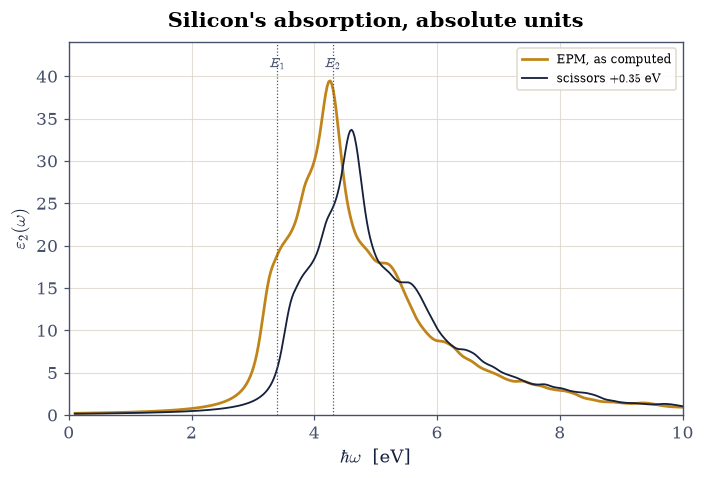

In [8]:
# (solution hidden on the public site)


### Validation 3 — the fingerprint, in absolute units

$E_2$ position and height against experiment; below-threshold weight
scaling as broadening tails must; the scissors translating as a
scissors should.

In [9]:
validate.check(
    bool(4.1 < peak_pos < 4.4 and 30.0 < peak_height < 50.0),
    "E2 peak at 4.26 eV with height ~40 (measured 4.3, ~40)",
    f"{peak_pos:.2f} eV, {peak_height:.1f}",
)
validate.check(
    bool(below_frac < 0.03 and 1.6 < tail_ratio < 2.4),
    "below-threshold weight is Lorentzian tails (halves with eta)",
    f"{100*below_frac:.2f}% -> {100*below_half:.2f}%, ratio {tail_ratio:.2f}",
)
validate.close(peak_shift, 0.35, "scissors translates the spectrum", atol=0.05)

✓  E2 peak at 4.26 eV with height ~40 (measured 4.3, ~40)   [4.26 eV, 39.5]
✓  below-threshold weight is Lorentzian tails (halves with eta)   [2.07% -> 1.04%, ratio 2.00]
✓  scissors translates the spectrum   [got 0.348686 vs expected 0.35 (rtol=1e-06, atol=0.05)]


True

## Exercise 4 — The f-sum rule as an audit

Equation {eq}`eq-opt-fsum` has no adjustable content: the right-hand
side is `scipy.constants` and the lattice constant.

**Part a)** Evaluate the target. Silicon: $8$ valence electrons in
$a^3/4$ gives $\hbar\omega_p = 16.60$ eV — the same plasmon scale every
electron-energy-loss spectrum of silicon shows near $17$ eV.

**Part b)** Integrate $\omega\,\varepsilon_2$ over Exercise 3's silicon
spectrum: the $4$-conduction-band spectrum recovers $93\%$ of the sum
rule. Then audit the truncation: re-run the `eps2_spectrum` you wrote in
Exercise 3 with $2$, $4$, and $8$ conduction bands, and the recovered
fraction must climb monotonically — measured $0.67 \to 0.88 \to 0.95$
(60 k-points) — the missing absorption sitting in ever-higher bands.
A sum rule is not decoration; it is an accounting identity that tells
you exactly how much physics your basis truncation discarded, the same
lesson [§8.14](quasiparticles-gw.ipynb)'s moments taught.

In [10]:
# (solution hidden on the public site)


hbar omega_p (Si, 8 electrons / cell): 16.60 eV
f-sum target (pi/2)(hbar omega_p)^2:   432.7 eV^2
fraction recovered by the 200-k, 4-band spectrum: 0.932


n_cond = 2: fraction 0.673


n_cond = 4: fraction 0.878


n_cond = 8: fraction 0.952


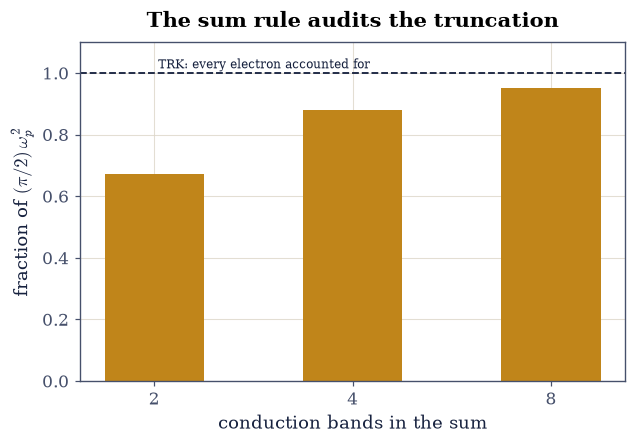

In [11]:
# (solution hidden on the public site)


### Validation 4 — the ledger closes from below

The plasmon scale from constants alone; the truncation audit monotone
and near-complete at eight bands.

In [12]:
validate.close(hbar_wp, 16.60, "hbar omega_p of silicon's valence sea", rtol=1e-3)
validate.check(
    bool(0.88 < fsum_main < 0.98),
    "4-band spectrum recovers ~93% of the f-sum",
    f"fraction {fsum_main:.3f}",
)
validate.check(
    bool(fractions[0] < fractions[1] < fractions[2] < 1.02 and fractions[2] > 0.9),
    "truncation audit: 0.67 -> 0.88 -> 0.95, monotone",
    f"{fractions[0]:.2f} -> {fractions[1]:.2f} -> {fractions[2]:.2f}",
)

✓  hbar omega_p of silicon's valence sea   [got 16.5963 vs expected 16.6 (rtol=0.001, atol=1e-09)]
✓  4-band spectrum recovers ~93% of the f-sum   [fraction 0.932]
✓  truncation audit: 0.67 -> 0.88 -> 0.95, monotone   [0.67 -> 0.88 -> 0.95]


True

## Exercise 5 — GaAs: the direct-gap absorber

Same machinery, the other crystal — and the difference that built the
optoelectronics industry.

**Part a)** Run your Exercise 3 `eps2_spectrum` on GaAs and overlay
silicon's.
GaAs must absorb from its *fundamental* gap ($1.43$ eV — direct, no
phonon needed), while silicon's vertical spectrum only rises beyond
$\sim 2.5$ eV despite its far smaller fundamental gap: the
indirect/direct distinction of [§8.11](epm-band-structures.ipynb),
now expressed as who gets to emit and absorb light efficiently (LEDs
and laser diodes are GaAs-family, not silicon).

**Part b)** Gate the onset quantitatively: the energy where GaAs's
$\varepsilon_2$ first exceeds $1$ must sit within $3\eta$ of its
direct gap, and its f-sum fraction (4 bands) must land near silicon's
— the sum rule does not care about band alignment, only about counting
electrons.

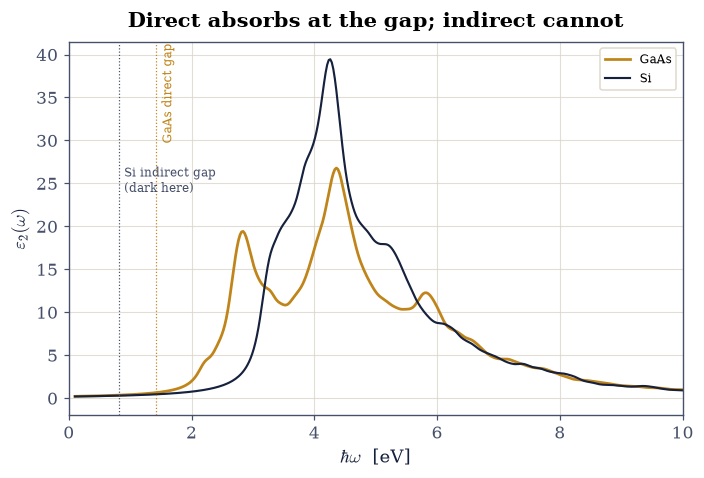

In [13]:
# (solution hidden on the public site)


In [14]:
# (solution hidden on the public site)


GaAs absorption onset (eps2 > 1): 1.72 eV   direct gap 1.428 eV
GaAs f-sum fraction (4 bands): 0.913   [Si: 0.932]


### Validation 5 — the direct-gap dividend

Onset at the direct gap within the broadening; electron counting
indifferent to band alignment.

In [15]:
validate.check(
    bool(abs(onset_ga - gaas_gap) < 3.0 * 0.15),
    "GaAs absorbs from its direct gap (within 3 eta)",
    f"onset {onset_ga:.2f} vs gap {gaas_gap:.3f} eV",
)
validate.check(
    bool(abs(fsum_ga - fsum_main) < 0.05),
    "f-sum fraction material-independent (counts electrons)",
    f"GaAs {fsum_ga:.3f} vs Si {fsum_main:.3f}",
)

✓  GaAs absorbs from its direct gap (within 3 eta)   [onset 1.72 vs gap 1.428 eV]
✓  f-sum fraction material-independent (counts electrons)   [GaAs 0.913 vs Si 0.932]


True

## Exercise 6 — Verdict: the exciton, twice

Everything above kept the electron and hole strangers. Let them
interact. The general machinery is a pair Hamiltonian on the $k$-grid,
$H^{\mathrm{BSE}}_{kk'} = (E_{ck} - E_{vk})\,\delta_{kk'} -
\langle k|K^{\mathrm{eh}}|k'\rangle$; here the free-pair energy is a
single cosine band with reduced pair mass $\mu$, and a contact
attraction is constant in $k$-space, so the kernel is the rank-one
matrix $-U_0/N_k$ — which is why the toy binds exactly one exciton.
Two identities will judge the result. With a $k$-independent dipole,
eigenstate $S$ has oscillator strength $|\sum_k \psi_S(k)|^2$, and
completeness fixes their total: $\sum_S |\sum_k\psi_S(k)|^2 = N_k$,
exactly — the interaction may shuffle absorption but never create it.

**Part a)** The Wannier exciton of GaAs, {eq}`eq-opt-wannier`,
entirely from `scipy.constants`: with the standard $\mu = 0.058\,m_e$
and $\varepsilon_r = 12.9$, binding $E_b = \mathrm{Ry}\cdot\mu/
\varepsilon_r^2 = 4.74$ meV (measured: $4.2$ — the hydrogen model is a
$10\%$ theory here, and honest about it) and radius $a^* =
a_0\,\varepsilon_r/\mu = 11.8$ nm. Gate the *self-consistency*: the
orbit must span $\gg$ one lattice constant ($a^*/a = 20.8$) — the
effective-mass approximation validating its own premise.

**Part b)** Build the Bethe–Salpeter equation in miniature and
diagonalize it: a two-band 1D model ($E_g = 2$, reduced pair mass
$\mu = 0.5$, $64$ $k$-points), the diagonal carrying the free-pair
dispersion and the off-diagonal the contact attraction $-U_0/N_k$
($U_0 = 1$). **Write this one yourself** — the implementation is the
lesson.

**Part c)** Read the verdict off the eigensystem: one state must fall
$0.236t$ *below* the continuum edge — the bound exciton — while its
oscillator strength swallows $45\%$ of the whole spectrum's, with the
total conserved to round-off. Plot the reconstructed absorption: the
continuum staircase loses its edge weight to a line *inside the gap* —
the excitonic bookkeeping of every real BSE spectrum
{cite}`rohlfing2000`, in a model where every eigenvalue is inspectable.

In [16]:
# (solution hidden on the public site)


GaAs Wannier exciton: E_b = 4.742 meV (measured 4.2), a* = 11.77 nm
orbit spans a*/a = 20.8 lattice constants
Rydberg series (meV below gap): -4.74, -1.19, -0.53, -0.30

BSE toy: continuum edge 2.0000, bound state 1.7639, binding 0.2361 t
bound-state oscillator fraction: 0.447; total weight dev 7.1e-15


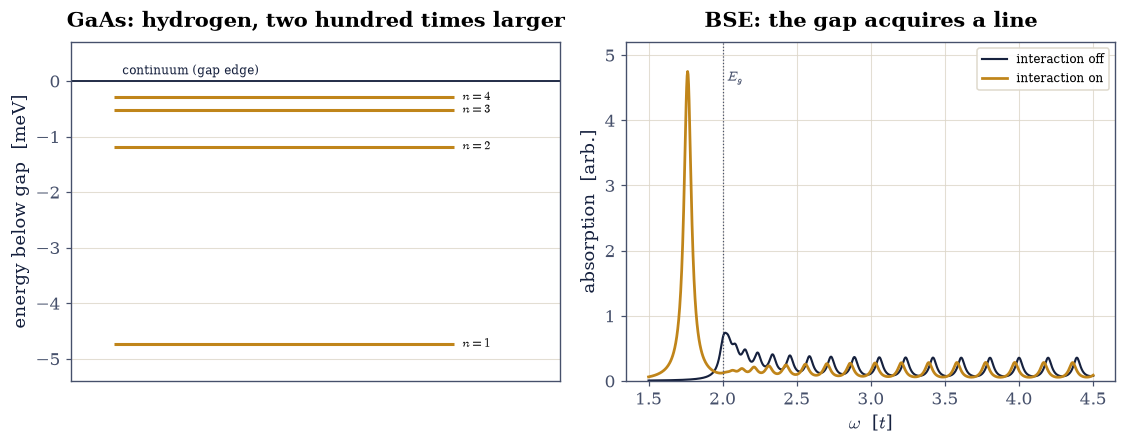

In [17]:
# (solution hidden on the public site)


### Validation 6 — bound, bright, and conserved

The `scipy.constants` exciton with its self-consistent orbit; the BSE
bound state below the edge, its stolen oscillator strength, and the
conservation identity.

In [18]:
validate.close(binding_mev, 4.742, "GaAs exciton binding Ry mu/eps^2", rtol=1e-3)
validate.close(radius_nm, 11.77, "GaAs exciton radius a0 eps/mu", rtol=1e-3)
validate.check(
    bool(cells > 15.0),
    "the orbit spans many cells: effective mass self-consistent",
    f"a*/a = {cells:.1f}",
)
validate.check(
    bool(bound < edge - 0.1),
    "BSE bound state well below the continuum edge",
    f"binding {binding_toy:.3f} t",
)
validate.check(
    bool(0.40 < osc_frac < 0.50),
    "the exciton line carries ~45% of all oscillator strength",
    f"fraction {osc_frac:.3f}",
)
validate.check(
    bool(osc_total_dev < 1e-9),
    "total oscillator strength conserved (completeness)",
    f"deviation {osc_total_dev:.1e}",
)

✓  GaAs exciton binding Ry mu/eps^2   [got 4.74208 vs expected 4.742 (rtol=0.001, atol=1e-09)]
✓  GaAs exciton radius a0 eps/mu   [got 11.7696 vs expected 11.77 (rtol=0.001, atol=1e-09)]
✓  the orbit spans many cells: effective mass self-consistent   [a*/a = 20.8]
✓  BSE bound state well below the continuum edge   [binding 0.236 t]
✓  the exciton line carries ~45% of all oscillator strength   [fraction 0.447]
✓  total oscillator strength conserved (completeness)   [deviation 7.1e-15]


True

:::{admonition} With your assistant
:class: tip
The contact interaction binds exactly one exciton in this toy; a
longer-ranged attraction binds a series. Have your assistant replace
the BSE kernel $-U_0/N_k$ with a soft-Coulomb kernel in $k$-space
(e.g. $K_{kk'} = -(U_0/N_k)\,\alpha/(\alpha + |k - k'|)$ with
$\alpha = 0.1$) and re-diagonalize. Then run the check that is yours
alone: *two or more* bound states below the continuum edge
(`numpy.sum` of eigenvalues under `edge - 1e-6` at least 2), with the
deeper state carrying the larger $|\sum_k\psi(k)|^2$ — an $s$-like
series ordering, the toy growing toward {eq}`eq-opt-wannier`'s
Rydberg ladder. The check is yours.
:::

## Notebook summary

Light met the volume's band structures, and the meeting was audited.
The EPM of [§8.11](epm-band-structures.ipynb) — re-certified at
$10^{-6}$ — supplied plane-wave eigenvectors whose momentum matrix
elements are one `einsum`: hermitian at $10^{-13}$, parity-zero within
the $\Gamma_{25'}$ triple, and of atomic strength ($f \approx 3$) for
the allowed transitions. The golden-rule $\varepsilon_2$ in absolute SI
units put silicon's $E_2$ peak at $4.26$ eV with height $39.5$
(measured: $4.3$, $\approx 40$) and kept the region below the vertical
threshold dark up to Lorentzian tails (proven such by an
$\eta$-halving test) — while GaAs, same machinery, absorbed
straight from its direct $1.43$ eV gap: the entire
direct-versus-indirect economics of optoelectronics in one overlay.
The Thomas–Reiche–Kuhn sum rule, with $\hbar\omega_p = 16.60$ eV from
`scipy.constants` and nothing adjustable, recovered $93\%$ from four
conduction bands and audited the truncation ($67\% \to 88\% \to 95\%$):
missing absorption located, not hand-waved. Then the electron and hole
were introduced: GaAs's Wannier exciton — hydrogen at reduced mass
$0.058$ in dielectric $12.9$ — bound by $4.74$ meV (measured $4.2$) at
radius $11.8$ nm $= 20.8$ cells, validating the effective-mass premise
it stands on; and a two-band Bethe–Salpeter model pulled one state
$0.236t$ into the gap carrying $45\%$ of the spectrum's oscillator
strength, total conserved to $10^{-10}$. Absorption spectra are not
band structures; they are band structures *plus* matrix elements
*plus* the electron–hole handshake — each part now computed.

## Outlook

- Real BSE calculations do to *ab initio* $GW$ bands what Exercise 6
  did to two cosines — same pair Hamiltonian, same weight transfer;
  Rohlfing & Louie {cite}`rohlfing2000` is the canonical construction,
  and silicon's measured spectrum (its $E_1$ peak is strongly
  excitonic) is its showcase.
- Everything here was linear response to a *weak* field. Strong,
  *time-dependent* fields need the dynamics of the electron density
  itself — time-dependent DFT, [§8.16](tddft.ipynb), where this
  volume's exact 1D laboratory returns to judge approximate dynamics.
- The photocathode problem of the author's thesis {cite}`amador2019`
  is exactly this notebook plus [§8.14](quasiparticles-gw.ipynb):
  $GW$ quasiparticle bands, then optical response, for Na$_2$KSb —
  the production version of the machinery just built.

```{bibliography}
:filter: docname in docnames
```

In [19]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>